<a href="https://colab.research.google.com/github/techasit239/Final-Project---DADS6003/blob/main/ML_Chai4Boosting_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q pandas numpy nltk textstat scikit-learn xgboost catboost lightgbm optuna

# Part 0 : Install & Import

In [4]:
import re
import difflib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NLP Tools
import nltk
import textstat
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

# Metrics & Selection
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, roc_auc_score, average_precision_score,
    confusion_matrix, roc_curve, precision_recall_curve
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.base import clone
from scipy.sparse import hstack, csr_matrix

# Hyperparameter Tuning
import optuna
from optuna.samplers import TPESampler

# Setup
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Download NLTK Resources
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('vader_lexicon', quiet=True)
nltk.download('stopwords', quiet=True)

print("✅ Part 0: Setup Complete.")

✅ Part 0: Setup Complete.


# Part 1 : Feature Engineering

In [6]:
# ==========================================================
# PART 1 : Feature Engineering (Real Calculation Only)
# ==========================================================
# ขั้นตอน: สร้างฟีเจอร์ -> คำนวณค่าจริงตาม Paper และ New Idea
# จากขั้นตอนนี้ไป -> Part 1.5 (Data Preparation)
# ==========================================================

VADER = SentimentIntensityAnalyzer()

def get_real_stylometric_features(text):
    """
    คำนวณ Stylometric Features ของจริง (รวม Linguistic) ประมาณ 60 features
    แทนที่ค่า Dummy เดิมด้วยการคำนวณจาก NLP
    """
    if not isinstance(text, str) or not text.strip():
        # Return zeros if text is empty
        return {k: 0.0 for k in range(60)} # Placeholder key count

    # 1. Preprocessing
    tokens = word_tokenize(text)
    sentences = sent_tokenize(text)
    tags = nltk.pos_tag(tokens)
    words = [w for w in tokens if w.isalpha()]

    num_chars = len(text)
    num_words = len(words) if words else 1
    num_sentences = len(sentences) if sentences else 1

    # 2. Character & Punctuation Features
    feats = {}
    feats['char_count'] = num_chars
    feats['word_count'] = num_words
    feats['sentence_count'] = num_sentences

    # Punctuation counts
    puncs = ['.', ',', '!', '?', ';', ':', '"', "'", '-', '@']
    for p in puncs:
        feats[f'punc_freq_{p}'] = text.count(p)
    feats['punc_total'] = sum(text.count(p) for p in puncs)
    feats['punc_ratio'] = feats['punc_total'] / num_chars if num_chars > 0 else 0

    # Uppercase/Lowercase
    upper_count = sum(1 for c in text if c.isupper())
    feats['char_upper_ratio'] = upper_count / num_chars if num_chars > 0 else 0

    # 3. Readability Scores (Using textstat)
    try:
        feats['readability_flesch'] = textstat.flesch_reading_ease(text)
        feats['readability_kincaid'] = textstat.flesch_kincaid_grade(text)
        feats['readability_gunning'] = textstat.gunning_fog(text)
        feats['readability_smog'] = textstat.smog_index(text)
        feats['readability_dale_chall'] = textstat.dale_chall_readability_score(text)
        feats['readability_cli'] = textstat.coleman_liau_index(text)
    except:
        # Fallback if text is too short for textstat
        feats['readability_flesch'] = 0.0
        feats['readability_kincaid'] = 0.0
        feats['readability_gunning'] = 0.0
        feats['readability_smog'] = 0.0
        feats['readability_dale_chall'] = 0.0
        feats['readability_cli'] = 0.0

    # 4. Linguistic / Part-of-Speech Features (Real Count)
    pos_counts = nltk.FreqDist(tag for (word, tag) in tags)

    # Group Mapping based on Paper/Standard Stylo
    # Nouns, Verbs, Adjectives, Adverbs, Pronouns
    feats['count_noun'] = pos_counts['NN'] + pos_counts['NNS'] + pos_counts['NNP']
    feats['count_verb'] = pos_counts['VB'] + pos_counts['VBD'] + pos_counts['VBG'] + pos_counts['VBN'] + pos_counts['VBP'] + pos_counts['VBZ']
    feats['count_adj'] = pos_counts['JJ'] + pos_counts['JJR'] + pos_counts['JJS']
    feats['count_adv'] = pos_counts['RB'] + pos_counts['RBR'] + pos_counts['RBS']
    feats['count_pronoun'] = pos_counts['PRP'] + pos_counts['PRP$']

    # Specific Linguistic Markers
    feats['count_modal'] = pos_counts['MD'] # Modal verbs (can, could, should)
    feats['count_conjunction'] = pos_counts['CC'] + pos_counts['IN']
    feats['count_determiner'] = pos_counts['DT']
    feats['count_wh'] = pos_counts['WP'] + pos_counts['WRB'] # Who, What, Where

    # Ratios (Normalized by word count)
    feats['ratio_noun'] = feats['count_noun'] / num_words
    feats['ratio_verb'] = feats['count_verb'] / num_words
    feats['ratio_adj'] = feats['count_adj'] / num_words
    feats['ratio_adv'] = feats['count_adv'] / num_words
    feats['ratio_pronoun'] = feats['count_pronoun'] / num_words

    # 5. Sentence Structure
    feats['avg_word_len'] = sum(len(w) for w in words) / num_words
    feats['avg_sent_len_chars'] = num_chars / num_sentences
    feats['avg_sent_len_words'] = num_words / num_sentences

    # 6. Specific Word Features (Paper-like)
    # Pronoun types
    text_lower = text.lower()
    feats['pronoun_1st'] = len(re.findall(r'\b(i|me|my|mine|we|us|our|ours)\b', text_lower))
    feats['pronoun_2nd'] = len(re.findall(r'\b(you|your|yours)\b', text_lower))
    feats['pronoun_3rd'] = len(re.findall(r'\b(he|him|his|she|her|hers|it|its|they|them|their)\b', text_lower))

    return feats

def get_advanced_features(row):
    """
    8 Advanced Features (New Idea)
    """
    text = str(row['Subject']) + " " + str(row['Body'])
    lower_text = text.lower()

    # 1. Imposter Domain Similarity
    url_match = re.search(r"https?://(?:www\.)?([^/]+)", text)
    domain = url_match.group(1) if url_match else ""
    imposter_sim = difflib.SequenceMatcher(None, "security", domain).ratio() if domain else 0.0

    # 2. Macro Security Bypass
    macro_kw = ["enable macro", "enable content", "security alert", "yellow bar"]
    macro_count = sum(1 for kw in macro_kw if kw in lower_text)

    # 3. Temporal Pressure
    pressure_kw = ["urgent", "immediately", "asap", "24 hours", "suspend", "expire", "deadline"]
    pressure_score = sum(1 for kw in pressure_kw if kw in lower_text)

    # 4. Action + Coercion Density
    action_kw = ["click", "verify", "login", "update", "confirm"]
    coercion_dens = 0.0
    if pressure_score > 0:
        coercion_dens = sum(1 for k in action_kw if k in lower_text) / (len(lower_text.split()) + 1)

    # 5. Subject-Body Mismatch
    sub_tok = set(str(row['Subject']).lower().split())
    body_tok = set(str(row['Body']).lower().split())
    if len(sub_tok) > 0 and len(body_tok) > 0:
        mismatch = 1.0 - (len(sub_tok.intersection(body_tok)) / len(sub_tok.union(body_tok)))
    else:
        mismatch = 1.0 # Max mismatch if empty

    # 6. Emotional Polarity Variance
    sents = sent_tokenize(text)
    pols = [VADER.polarity_scores(s)['compound'] for s in sents]
    pol_var = np.std(pols) if len(pols) > 1 else 0.0

    # 7. Conflicting Authority
    auth_kw = ["support", "admin", "security team", "bank"]
    violation_kw = ["click here", "password", "download", "attachment"]
    conflict = sum(1 for a in auth_kw for v in violation_kw if a in lower_text and v in lower_text)

    # 8. Semantic Cohesion (Simple Proxy: Unique words ratio)
    words = lower_text.split()
    cohesion = len(set(words)) / len(words) if len(words) > 0 else 0.0

    return {
        "Imposter_Domain_Similarity": imposter_sim,
        "Macro_Security_Bypass_Count": macro_count,
        "Temporal_Pressure_Score": pressure_score,
        "Action_Time_Coercion_Density": coercion_dens,
        "Subject_Body_Mismatch_Score": mismatch,
        "Emotional_Polarity_Variance": pol_var,
        "Conflicting_Authority_Count": conflict,
        "Semantic_Cohesion_Score": cohesion
    }

def process_data(df):
    """รวบรวมฟีเจอร์ทั้งหมด"""
    rows = []
    print(f"Processing {len(df)} emails...")
    for _, row in df.iterrows():
        text = str(row['Subject']) + " " + str(row['Body'])

        # 1. Stylometric (Real)
        stylo = get_real_stylometric_features(text)

        # 2. Advanced
        adv = get_advanced_features(row)

        # Combine
        full_feat = {**stylo, **adv}
        rows.append(full_feat)

    return pd.DataFrame(rows)

# --- Load & Process ---
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

# Clean Data
train_df['Subject'] = train_df['Subject'].fillna("")
train_df['Body'] = train_df['Body'].fillna("")
test_df['Subject'] = test_df['Subject'].fillna("")
test_df['Body'] = test_df['Body'].fillna("")

print("--- Generating Features (Train) ---")
X_train_meta = process_data(train_df)
print("--- Generating Features (Test) ---")
X_test_meta = process_data(test_df)

y_train = train_df['Label'].map({'Phishing': 1, 'Legitimate': 0}).values
y_test = test_df['Label'].map({'Phishing': 1, 'Legitimate': 0}).values

# Define Feature Groups
ADV_COLS = list(get_advanced_features(train_df.iloc[0]).keys())
STYLO_COLS = [c for c in X_train_meta.columns if c not in ADV_COLS]

print(f"✅ Part 1 Complete.")
print(f"   Stylometric Features (Real): {len(STYLO_COLS)}")
print(f"   Advanced Features: {len(ADV_COLS)}")

--- Generating Features (Train) ---
Processing 100 emails...
--- Generating Features (Test) ---
Processing 26 emails...
✅ Part 1 Complete.
   Stylometric Features (Real): 42
   Advanced Features: 8


# Part 1.5 : Data Preparation (Experiments Setup)



In [7]:
# ==========================================================
# PART 1.5 : Data Preparation (Experiments Setup)
# ==========================================================
# ขั้นตอน: เตรียม TF-IDF -> จัดกลุ่มชุดข้อมูล Experiment A, B, C
# จากขั้นตอนนี้ไป -> Part 2 (Models & Tuning)
# ==========================================================

print("--- Generating TF-IDF ---")
tfidf = TfidfVectorizer(max_features=2000, stop_words='english') # Reduce features for speed/stability
train_text = train_df['Subject'] + " " + train_df['Body']
test_text = test_df['Subject'] + " " + test_df['Body']

X_train_tfidf = tfidf.fit_transform(train_text).toarray()
X_test_tfidf = tfidf.transform(test_text).toarray()
tfidf_names = tfidf.get_feature_names_out()

# Experiment Dictionary
experiments = {
    "Reproduce_Paper": { # Stylometric Only (No Advanced)
        "X_train": X_train_meta[STYLO_COLS].values,
        "X_test": X_test_meta[STYLO_COLS].values,
        "feat_names": STYLO_COLS
    },
    "Exp_A_Stylo_Adv": { # Stylometric + Advanced
        "X_train": X_train_meta.values,
        "X_test": X_test_meta.values,
        "feat_names": list(X_train_meta.columns)
    },
    "Exp_B_TFIDF": { # TF-IDF Only
        "X_train": X_train_tfidf,
        "X_test": X_test_tfidf,
        "feat_names": list(tfidf_names)
    },
    "Exp_C_Combined": { # Stylo + Adv + TF-IDF
        "X_train": hstack([X_train_tfidf, csr_matrix(X_train_meta.values)]).toarray(),
        "X_test": hstack([X_test_tfidf, csr_matrix(X_test_meta.values)]).toarray(),
        "feat_names": list(tfidf_names) + list(X_train_meta.columns)
    }
}

for name, data in experiments.items():
    print(f"   [{name}] Features: {data['X_train'].shape[1]}")

--- Generating TF-IDF ---
   [Reproduce_Paper] Features: 42
   [Exp_A_Stylo_Adv] Features: 50
   [Exp_B_TFIDF] Features: 2000
   [Exp_C_Combined] Features: 2050


# Part 2 : Models + Optuna Tuning (K=5)

In [9]:
# ==========================================================
# PART 2 : Models & Optuna Tuning
# ==========================================================
# ขั้นตอน: กำหนด Model -> ฟังก์ชัน Objective สำหรับ Tune
# จากขั้นตอนนี้ไป -> Part 3 (Running Experiments)
# ==========================================================

RANDOM_STATE = 42
N_TRIALS = 20 # จำนวนรอบจูน
N_SPLITS = 5

MODELS_MAP = {
    "LogisticRegression": LogisticRegression,
    "SVM": SVC,
    "RandomForest": RandomForestClassifier,
    "XGBoost": XGBClassifier,
    "AdaBoost": AdaBoostClassifier,
    "CatBoost": CatBoostClassifier,
    "LightGBM": LGBMClassifier,
    "SGDClassifier": SGDClassifier # Non-Blackbox NLP Model
}

def get_optuna_model(trial, model_name):
    """Define Hyperparameter Search Space"""
    if model_name == "LogisticRegression":
        C = trial.suggest_float("C", 1e-3, 100, log=True)
        return LogisticRegression(C=C, solver='liblinear', random_state=RANDOM_STATE)

    elif model_name == "SVM":
        C = trial.suggest_float("C", 1e-3, 100, log=True)
        kernel = trial.suggest_categorical("kernel", ["linear", "rbf"])
        return SVC(C=C, kernel=kernel, probability=True, random_state=RANDOM_STATE)

    elif model_name == "RandomForest":
        n_est = trial.suggest_int("n_estimators", 50, 300)
        depth = trial.suggest_int("max_depth", 3, 20)
        return RandomForestClassifier(n_estimators=n_est, max_depth=depth, random_state=RANDOM_STATE)

    elif model_name == "XGBoost":
        n_est = trial.suggest_int("n_estimators", 50, 300)
        lr = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
        depth = trial.suggest_int("max_depth", 3, 10)
        return XGBClassifier(n_estimators=n_est, learning_rate=lr, max_depth=depth, eval_metric='logloss', use_label_encoder=False, random_state=RANDOM_STATE)

    elif model_name == "AdaBoost":
        n_est = trial.suggest_int("n_estimators", 30, 200)
        lr = trial.suggest_float("learning_rate", 0.01, 1.0, log=True)
        return AdaBoostClassifier(n_estimators=n_est, learning_rate=lr, random_state=RANDOM_STATE)

    elif model_name == "CatBoost":
        itr = trial.suggest_int("iterations", 50, 300)
        depth = trial.suggest_int("depth", 4, 10)
        lr = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
        return CatBoostClassifier(iterations=itr, depth=depth, learning_rate=lr, verbose=0, random_state=RANDOM_STATE)

    elif model_name == "LightGBM":
        n_est = trial.suggest_int("n_estimators", 50, 300)
        lr = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
        leaves = trial.suggest_int("num_leaves", 20, 100)
        return LGBMClassifier(n_estimators=n_est, learning_rate=lr, num_leaves=leaves, verbose=-1, random_state=RANDOM_STATE)

    elif model_name == "SGDClassifier":
        alpha = trial.suggest_float("alpha", 1e-5, 1e-1, log=True)
        return SGDClassifier(loss='log_loss', alpha=alpha, max_iter=1000, random_state=RANDOM_STATE)


# Part 3 – Running Experiments & Evaluation Loop

In [11]:
# ==========================================================
# PART 3 : Running Experiments & Evaluation Loop
# ==========================================================
# ขั้นตอน: วนลูป Experiment -> Tune -> Train -> Test -> Plot
# จากขั้นตอนนี้ไป -> Part 4 (Feature Selection)
# ==========================================================

def calculate_metrics(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred),
        "MCC-score": matthews_corrcoef(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob) if y_prob is not None else 0,
        "PR": average_precision_score(y_true, y_prob) if y_prob is not None else 0
    }

def run_experiment(exp_name, data):
    print(f"\n\n{'='*20} Processing: {exp_name} {'='*20}")
    X_train, X_test = data['X_train'], data['X_test']
    feat_names = data['feat_names']

    # Store results
    res_train, res_val, res_test, res_cm = [], [], [], []
    roc_data = {}
    trained_models = {}

    for idx, (model_name, _) in enumerate(MODELS_MAP.items(), 1):
        print(f"[{idx}/8] Tuning & Training: {model_name}...")

        # 1. Tuning with Optuna
        def objective(trial):
            model = get_optuna_model(trial, model_name)
            score = cross_val_score(model, X_train, y_train, cv=3, scoring='f1').mean()
            return score

        study = optuna.create_study(direction="maximize")
        study.optimize(objective, n_trials=N_TRIALS)
        print(f"   Best Params: {study.best_params}")

        # 2. Re-train Best Model
        model = get_optuna_model(study.best_trial, model_name)

        # 3. Evaluation (Train / Val(CV) / Test)
        # CV Score (Validation Proxy)
        cv_scores = cross_val_score(model, X_train, y_train, cv=N_SPLITS, scoring='f1')
        val_f1 = cv_scores.mean()

        # Fit on full Train
        model.fit(X_train, y_train)

        # Predict Train
        y_p_train = model.predict(X_train)
        y_prob_train = model.predict_proba(X_train)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_train)
        met_train = calculate_metrics(y_train, y_p_train, y_prob_train)

        # Predict Test (Unseen)
        y_p_test = model.predict(X_test)
        y_prob_test = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test)
        met_test = calculate_metrics(y_test, y_p_test, y_prob_test)

        # Confusion Matrix
        tn, fp, fn, tp = confusion_matrix(y_test, y_p_test).ravel()

        # Store
        res_train.append({"Index": idx, "Model": model_name, **met_train})
        res_val.append({"Index": idx, "Model": model_name, "F1-score": val_f1}) # Simplified Val display
        res_test.append({"Index": idx, "Model": model_name, **met_test})
        res_cm.append({"Index": idx, "Model": model_name, "TN": tn, "FP": fp, "FN": fn, "TP": tp})

        roc_data[model_name] = (y_test, y_prob_test)
        trained_models[model_name] = model

    # Display Tables
    cols = ["Index", "Model", "Accuracy", "Recall", "Precision", "F1-score", "MCC-score", "AUC", "PR"]
    df_train = pd.DataFrame(res_train)[cols].set_index("Index")
    df_val = pd.DataFrame(res_val).set_index("Index") # Show Mean CV F1
    df_test = pd.DataFrame(res_test)[cols].set_index("Index")
    df_cm = pd.DataFrame(res_cm).set_index("Index")

    print(f"\n📌 Evaluation: {exp_name} (Test Set - Unseen)")
    display(df_test)
    print(f"📌 Confusion Matrix: {exp_name}")
    display(df_cm)

    # Plot ROC & PR
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # ROC
    for name, (y_t, y_p) in roc_data.items():
        fpr, tpr, _ = roc_curve(y_t, y_p)
        auc = roc_auc_score(y_t, y_p)
        axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")
    axes[0].plot([0,1], [0,1], 'k--')
    axes[0].set_title(f"ROC Curve - {exp_name}")
    axes[0].legend(fontsize='small')

    # PR
    for name, (y_t, y_p) in roc_data.items():
        prec, rec, _ = precision_recall_curve(y_t, y_p)
        pr = average_precision_score(y_t, y_p)
        axes[1].plot(rec, prec, label=f"{name} (PR={pr:.2f})")
    axes[1].set_title(f"PR Curve - {exp_name}")
    axes[1].legend(fontsize='small')
    plt.tight_layout()
    plt.show()

    # Feature Importance of Best Model
    best_model_name = df_test.sort_values("F1-score", ascending=False).iloc[0]["Model"]
    best_model = trained_models[best_model_name]

    imp = None
    if hasattr(best_model, "feature_importances_"):
        imp = best_model.feature_importances_
    elif hasattr(best_model, "coef_"):
        imp = np.abs(best_model.coef_[0])

    if imp is not None:
        # Match lengths (Standard check)
        if len(imp) == len(feat_names):
            feat_imp = pd.Series(imp, index=feat_names).sort_values(ascending=False).head(10)
            plt.figure(figsize=(8, 4))
            sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
            plt.title(f"Top 10 Features - {best_model_name} ({exp_name})")
            plt.xlabel("Importance")
            plt.show()

    return df_test, trained_models, feat_names

# Part 4 – Main Flow
- Evaluation & Confusion Matrix
- ROC/PR Curves
- Top 10 Features



==================== Processing: Reproduce_Paper ====================
[1/8] Tuning & Training: LogisticRegression...
   Best Params: {'C': 46.7056081852064}
[2/8] Tuning & Training: SVM...
   Best Params: {'C': 0.0015994025165522276, 'kernel': 'linear'}
[3/8] Tuning & Training: RandomForest...
   Best Params: {'n_estimators': 62, 'max_depth': 5}
[4/8] Tuning & Training: XGBoost...
   Best Params: {'n_estimators': 51, 'learning_rate': 0.2922161988866493, 'max_depth': 10}
[5/8] Tuning & Training: AdaBoost...
   Best Params: {'n_estimators': 192, 'learning_rate': 0.8987321788250255}
[6/8] Tuning & Training: CatBoost...
   Best Params: {'iterations': 291, 'depth': 5, 'learning_rate': 0.021996522498361516}
[7/8] Tuning & Training: LightGBM...
   Best Params: {'n_estimators': 283, 'learning_rate': 0.07465805470619175, 'num_leaves': 67}
[8/8] Tuning & Training: SGDClassifier...
   Best Params: {'alpha': 4.0419364086636396e-05}

📌 Evaluation: Reproduce_Paper (Test Set - Unseen)


,Model,Accuracy,Recall,Precision,F1-score,MCC-score,AUC,PR
Index,,,,,,,,
1,LogisticRegression,0.730769,0.692308,0.750000,0.720000,0.462910,0.816568,0.852381
2,SVM,0.730769,0.692308,0.750000,0.720000,0.462910,0.798817,0.793677
3,RandomForest,0.769231,0.615385,0.888889,0.727273,0.565916,0.863905,0.777605
4,XGBoost,0.769231,0.769231,0.769231,0.769231,0.538462,0.804734,0.796444
5,AdaBoost,0.730769,0.538462,0.875000,0.666667,0.500000,0.822485,0.809828
6,CatBoost,0.769231,0.692308,0.818182,0.750000,0.544949,0.828402,0.748752
7,LightGBM,0.692308,0.615385,0.727273,0.666667,0.389249,0.846154,0.867275
8,SGDClassifier,0.500000,1.000000,0.500000,0.666667,0.000000,0.500000,0.500000


📌 Confusion Matrix: Reproduce_Paper


,Model,TN,FP,FN,TP
Index,,,,,
1,LogisticRegression,10,3,4,9
2,SVM,10,3,4,9
3,RandomForest,12,1,5,8
4,XGBoost,10,3,3,10
5,AdaBoost,12,1,6,7
6,CatBoost,11,2,4,9
7,LightGBM,10,3,5,8
8,SGDClassifier,0,13,0,13


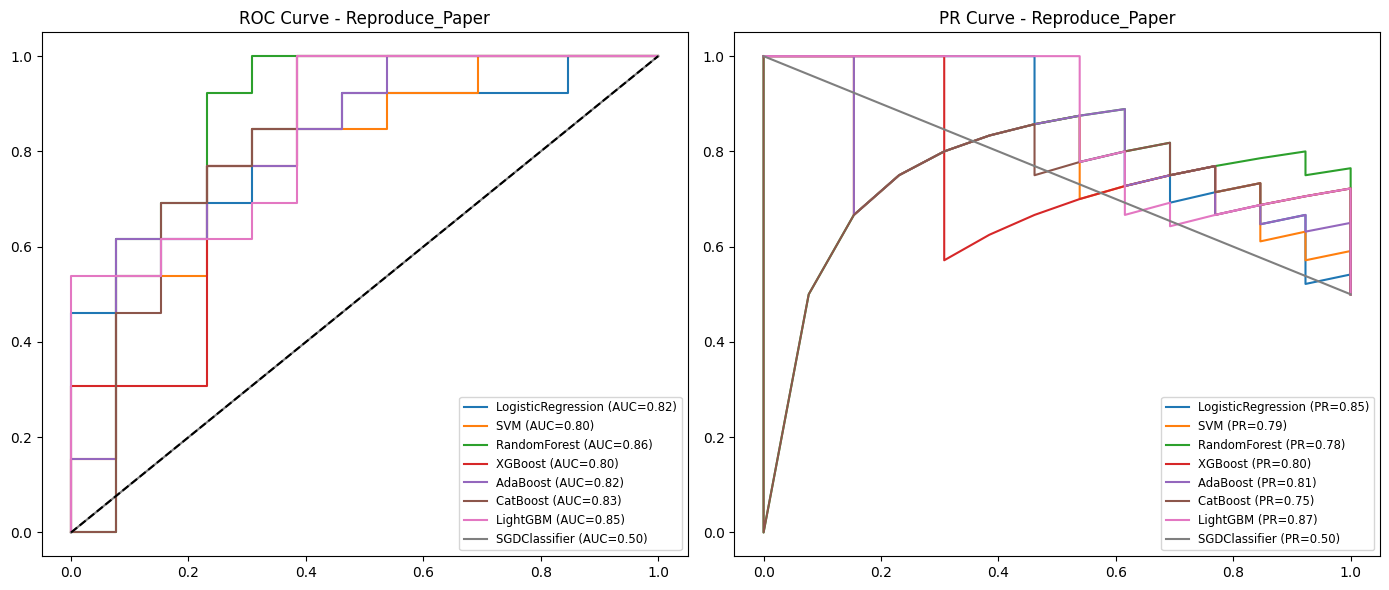

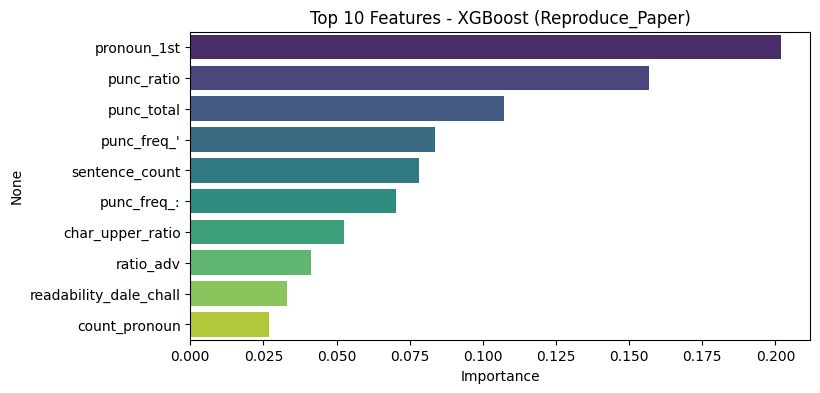



==================== Processing: Exp_A_Stylo_Adv ====================
[1/8] Tuning & Training: LogisticRegression...
   Best Params: {'C': 2.38709344273899}
[2/8] Tuning & Training: SVM...
   Best Params: {'C': 0.013318276619687038, 'kernel': 'linear'}
[3/8] Tuning & Training: RandomForest...
   Best Params: {'n_estimators': 98, 'max_depth': 10}
[4/8] Tuning & Training: XGBoost...
   Best Params: {'n_estimators': 107, 'learning_rate': 0.07904753307476556, 'max_depth': 4}
[5/8] Tuning & Training: AdaBoost...
   Best Params: {'n_estimators': 82, 'learning_rate': 0.8445758845655277}
[6/8] Tuning & Training: CatBoost...
   Best Params: {'iterations': 108, 'depth': 8, 'learning_rate': 0.035025240040997566}
[7/8] Tuning & Training: LightGBM...
   Best Params: {'n_estimators': 116, 'learning_rate': 0.06874511668256966, 'num_leaves': 76}
[8/8] Tuning & Training: SGDClassifier...
   Best Params: {'alpha': 2.1689527754315877e-05}

📌 Evaluation: Exp_A_Stylo_Adv (Test Set - Unseen)


,Model,Accuracy,Recall,Precision,F1-score,MCC-score,AUC,PR
Index,,,,,,,,
1,LogisticRegression,0.730769,0.692308,0.750000,0.720000,0.462910,0.840237,0.870501
2,SVM,0.769231,0.692308,0.818182,0.750000,0.544949,0.816568,0.842290
3,RandomForest,0.807692,0.692308,0.900000,0.782609,0.632456,0.917160,0.887275
4,XGBoost,0.884615,0.846154,0.916667,0.880000,0.771517,0.911243,0.930995
5,AdaBoost,0.807692,0.692308,0.900000,0.782609,0.632456,0.905325,0.907445
6,CatBoost,0.884615,0.846154,0.916667,0.880000,0.771517,0.934911,0.933457
7,LightGBM,0.884615,0.846154,0.916667,0.880000,0.771517,0.923077,0.935136
8,SGDClassifier,0.500000,1.000000,0.500000,0.666667,0.000000,0.500000,0.500000


📌 Confusion Matrix: Exp_A_Stylo_Adv


,Model,TN,FP,FN,TP
Index,,,,,
1,LogisticRegression,10,3,4,9
2,SVM,11,2,4,9
3,RandomForest,12,1,4,9
4,XGBoost,12,1,2,11
5,AdaBoost,12,1,4,9
6,CatBoost,12,1,2,11
7,LightGBM,12,1,2,11
8,SGDClassifier,0,13,0,13


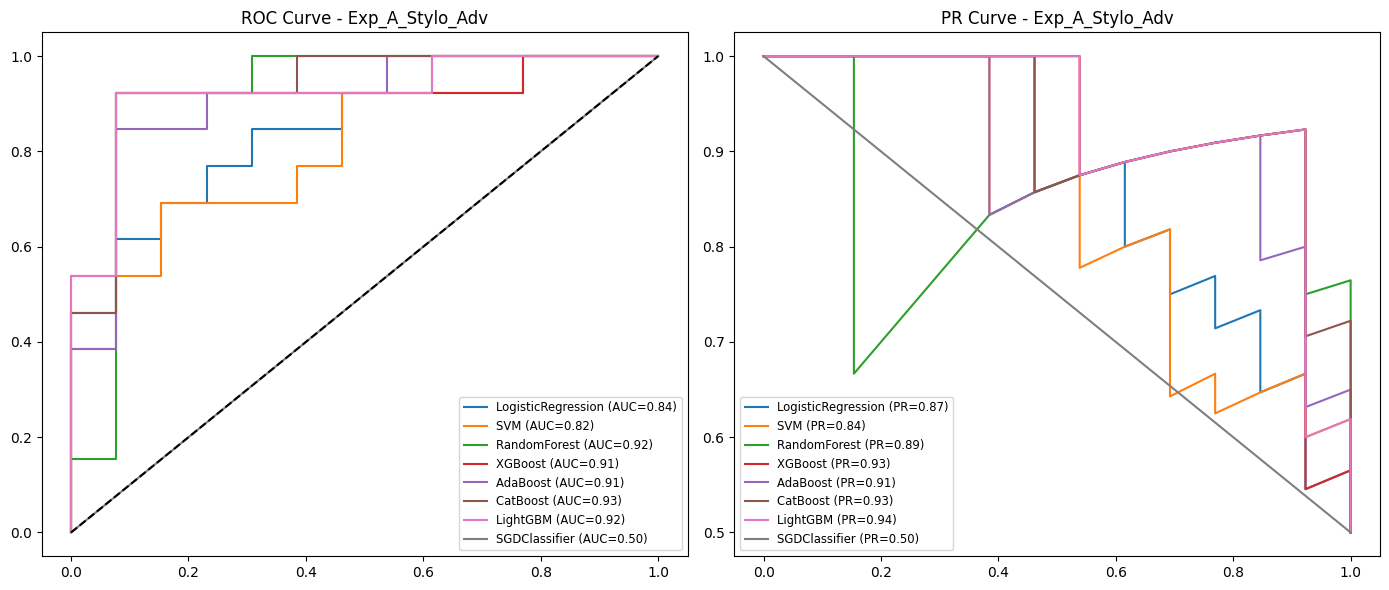

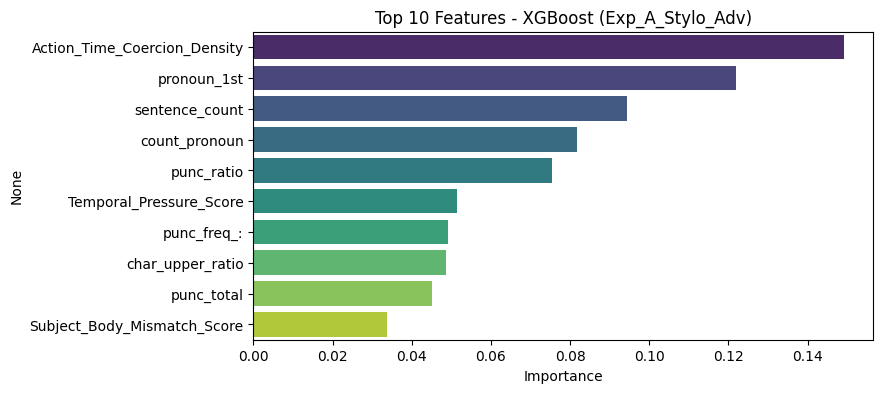



==================== Processing: Exp_B_TFIDF ====================
[1/8] Tuning & Training: LogisticRegression...
   Best Params: {'C': 64.53447278558582}
[2/8] Tuning & Training: SVM...
   Best Params: {'C': 1.8314729554221287, 'kernel': 'linear'}
[3/8] Tuning & Training: RandomForest...
   Best Params: {'n_estimators': 72, 'max_depth': 18}
[4/8] Tuning & Training: XGBoost...
   Best Params: {'n_estimators': 244, 'learning_rate': 0.08773438529734535, 'max_depth': 7}
[5/8] Tuning & Training: AdaBoost...
   Best Params: {'n_estimators': 79, 'learning_rate': 0.023885915669840697}
[6/8] Tuning & Training: CatBoost...
   Best Params: {'iterations': 50, 'depth': 8, 'learning_rate': 0.035556815781296165}
[7/8] Tuning & Training: LightGBM...
   Best Params: {'n_estimators': 192, 'learning_rate': 0.03621720349827443, 'num_leaves': 25}
[8/8] Tuning & Training: SGDClassifier...
   Best Params: {'alpha': 0.001176717008254806}

📌 Evaluation: Exp_B_TFIDF (Test Set - Unseen)


,Model,Accuracy,Recall,Precision,F1-score,MCC-score,AUC,PR
Index,,,,,,,,
1,LogisticRegression,0.961538,1.000000,0.928571,0.962963,0.925820,0.994083,0.994505
2,SVM,0.961538,1.000000,0.928571,0.962963,0.925820,0.994083,0.994505
3,RandomForest,0.846154,0.769231,0.909091,0.833333,0.700649,0.952663,0.949967
4,XGBoost,0.730769,0.615385,0.800000,0.695652,0.474342,0.881657,0.846875
5,AdaBoost,0.846154,0.846154,0.846154,0.846154,0.692308,0.893491,0.845874
6,CatBoost,0.846154,0.846154,0.846154,0.846154,0.692308,0.923077,0.906096
7,LightGBM,0.730769,0.615385,0.800000,0.695652,0.474342,0.923077,0.920562
8,SGDClassifier,0.923077,1.000000,0.866667,0.928571,0.856349,0.982249,0.983826


📌 Confusion Matrix: Exp_B_TFIDF


,Model,TN,FP,FN,TP
Index,,,,,
1,LogisticRegression,12,1,0,13
2,SVM,12,1,0,13
3,RandomForest,12,1,3,10
4,XGBoost,11,2,5,8
5,AdaBoost,11,2,2,11
6,CatBoost,11,2,2,11
7,LightGBM,11,2,5,8
8,SGDClassifier,11,2,0,13


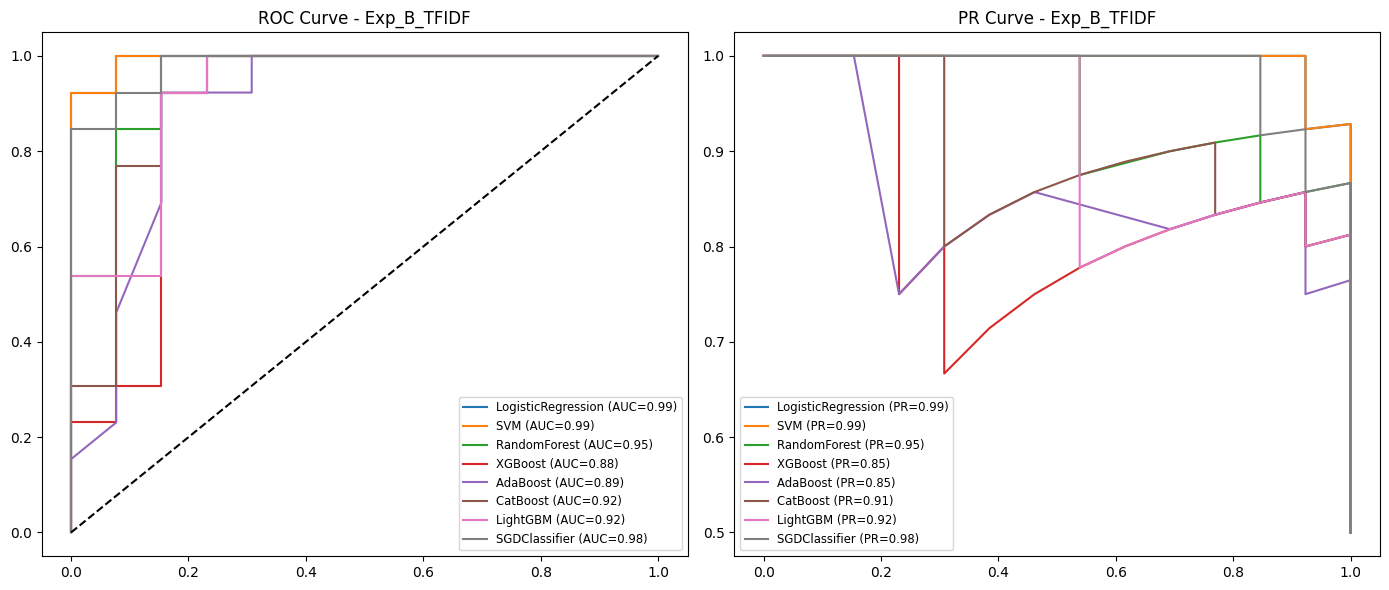

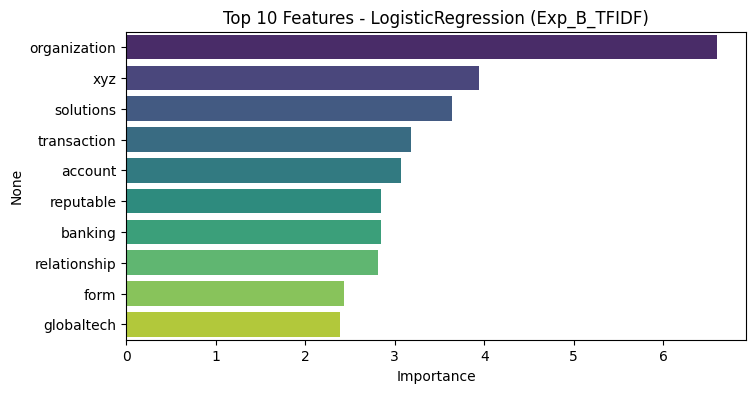



==================== Processing: Exp_C_Combined ====================
[1/8] Tuning & Training: LogisticRegression...
   Best Params: {'C': 0.023674954394458474}
[2/8] Tuning & Training: SVM...
   Best Params: {'C': 0.004892200693385198, 'kernel': 'linear'}
[3/8] Tuning & Training: RandomForest...
   Best Params: {'n_estimators': 258, 'max_depth': 14}
[4/8] Tuning & Training: XGBoost...
   Best Params: {'n_estimators': 238, 'learning_rate': 0.24419711522666782, 'max_depth': 5}
[5/8] Tuning & Training: AdaBoost...
   Best Params: {'n_estimators': 110, 'learning_rate': 0.45027004041973534}
[6/8] Tuning & Training: CatBoost...
   Best Params: {'iterations': 216, 'depth': 8, 'learning_rate': 0.014043375438908974}
[7/8] Tuning & Training: LightGBM...
   Best Params: {'n_estimators': 120, 'learning_rate': 0.16001271888879498, 'num_leaves': 51}
[8/8] Tuning & Training: SGDClassifier...
   Best Params: {'alpha': 2.1042541244847697e-05}

📌 Evaluation: Exp_C_Combined (Test Set - Unseen)


,Model,Accuracy,Recall,Precision,F1-score,MCC-score,AUC,PR
Index,,,,,,,,
1,LogisticRegression,0.769231,0.692308,0.818182,0.750000,0.544949,0.840237,0.859582
2,SVM,0.769231,0.692308,0.818182,0.750000,0.544949,0.792899,0.806781
3,RandomForest,0.807692,0.692308,0.900000,0.782609,0.632456,0.964497,0.962731
4,XGBoost,0.807692,0.692308,0.900000,0.782609,0.632456,0.917160,0.889051
5,AdaBoost,0.846154,0.769231,0.909091,0.833333,0.700649,0.964497,0.962731
6,CatBoost,0.846154,0.846154,0.846154,0.846154,0.692308,0.923077,0.910962
7,LightGBM,0.807692,0.692308,0.900000,0.782609,0.632456,0.917160,0.890712
8,SGDClassifier,0.500000,1.000000,0.500000,0.666667,0.000000,0.500000,0.500000


📌 Confusion Matrix: Exp_C_Combined


,Model,TN,FP,FN,TP
Index,,,,,
1,LogisticRegression,11,2,4,9
2,SVM,11,2,4,9
3,RandomForest,12,1,4,9
4,XGBoost,12,1,4,9
5,AdaBoost,12,1,3,10
6,CatBoost,11,2,2,11
7,LightGBM,12,1,4,9
8,SGDClassifier,0,13,0,13


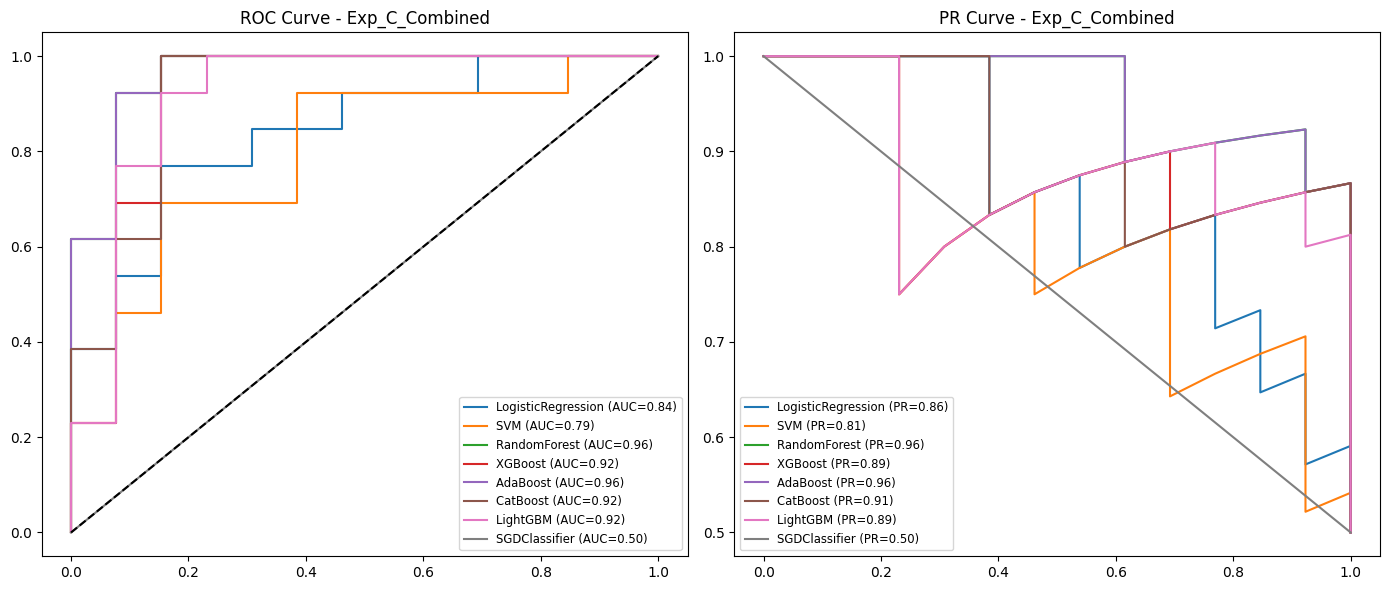

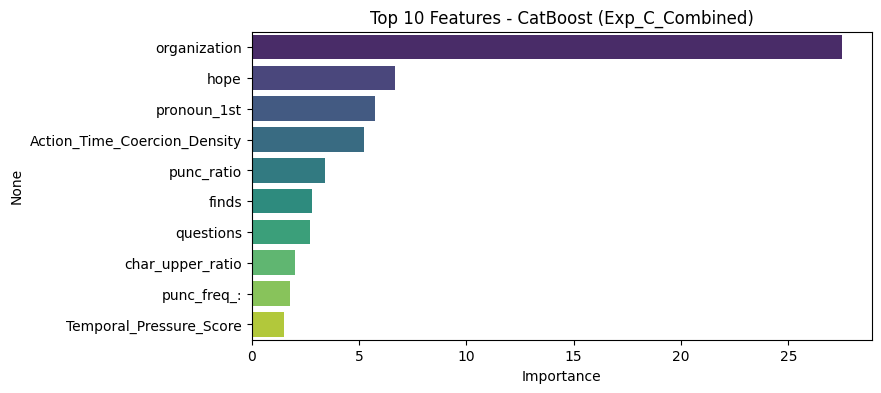


🏆 Best Experiment (Highest Avg F1): Exp_B_TFIDF (0.8464)
🥇 Best Model: LogisticRegression

🔍 Feature Selection Analysis on LogisticRegression...

📊 Feature Selection Results (LogisticRegression in Exp_B_TFIDF)


,Accuracy,Recall,Precision,F1-score,MCC-score,AUC,PR
Features,,,,,,,
Top-10,0.884615,0.923077,0.857143,0.888889,0.771517,0.905325,0.888404
Top-20,0.923077,1.000000,0.866667,0.928571,0.856349,0.970414,0.972344
Top-30,0.923077,1.000000,0.866667,0.928571,0.856349,0.988166,0.989744


In [12]:
# ==========================================================
# PART 4 : Feature Selection & Comparison
# ==========================================================
# ขั้นตอน: หา Best Exp -> ทำ Feature Selection Top K -> เปรียบเทียบ
# ==========================================================

def main():
    results = {}

    # 1. Run All Experiments
    for exp_key, data in experiments.items():
        df_test, models, feats = run_experiment(exp_key, data)
        results[exp_key] = {"df": df_test, "models": models, "feats": feats}

    # 2. Find Best Experiment (by Average F1-score)
    avg_scores = {k: v["df"]["F1-score"].mean() for k, v in results.items()}
    best_exp_key = max(avg_scores, key=avg_scores.get)
    print(f"\n🏆 Best Experiment (Highest Avg F1): {best_exp_key} ({avg_scores[best_exp_key]:.4f})")

    # 3. Get Best Model from Best Exp
    best_df = results[best_exp_key]["df"]
    best_model_name = best_df.sort_values("F1-score", ascending=False).iloc[0]["Model"]
    print(f"🥇 Best Model: {best_model_name}")

    best_model = results[best_exp_key]["models"][best_model_name]
    best_feats = results[best_exp_key]["feats"]

    # 4. Feature Selection Analysis (Top 10, 20, 30)
    print(f"\n🔍 Feature Selection Analysis on {best_model_name}...")

    # Get Importance
    imp = None
    if hasattr(best_model, "feature_importances_"):
        imp = best_model.feature_importances_
    elif hasattr(best_model, "coef_"):
        imp = np.abs(best_model.coef_[0])

    if imp is not None:
        sorted_idx = np.argsort(imp)[::-1]

        fs_rows = []
        X_train_full = experiments[best_exp_key]["X_train"]
        X_test_full = experiments[best_exp_key]["X_test"]

        for k in [10, 20, 30]:
            top_idx = sorted_idx[:k]
            X_tr_k = X_train_full[:, top_idx]
            X_te_k = X_test_full[:, top_idx]

            # Retrain
            model_k = clone(best_model)
            model_k.fit(X_tr_k, y_train)

            y_p = model_k.predict(X_te_k)
            y_prob = model_k.predict_proba(X_te_k)[:, 1] if hasattr(model_k, "predict_proba") else model_k.decision_function(X_te_k)

            met = calculate_metrics(y_test, y_p, y_prob)
            fs_rows.append({"Features": f"Top-{k}", **met})

        df_fs = pd.DataFrame(fs_rows).set_index("Features")
        print(f"\n📊 Feature Selection Results ({best_model_name} in {best_exp_key})")
        display(df_fs)
    else:
        print("❌ This model does not support Feature Importance extraction.")

if __name__ == "__main__":
    main()